# Efficiency Plot

/tmp/ipykernel_458/1514152537.py:119: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

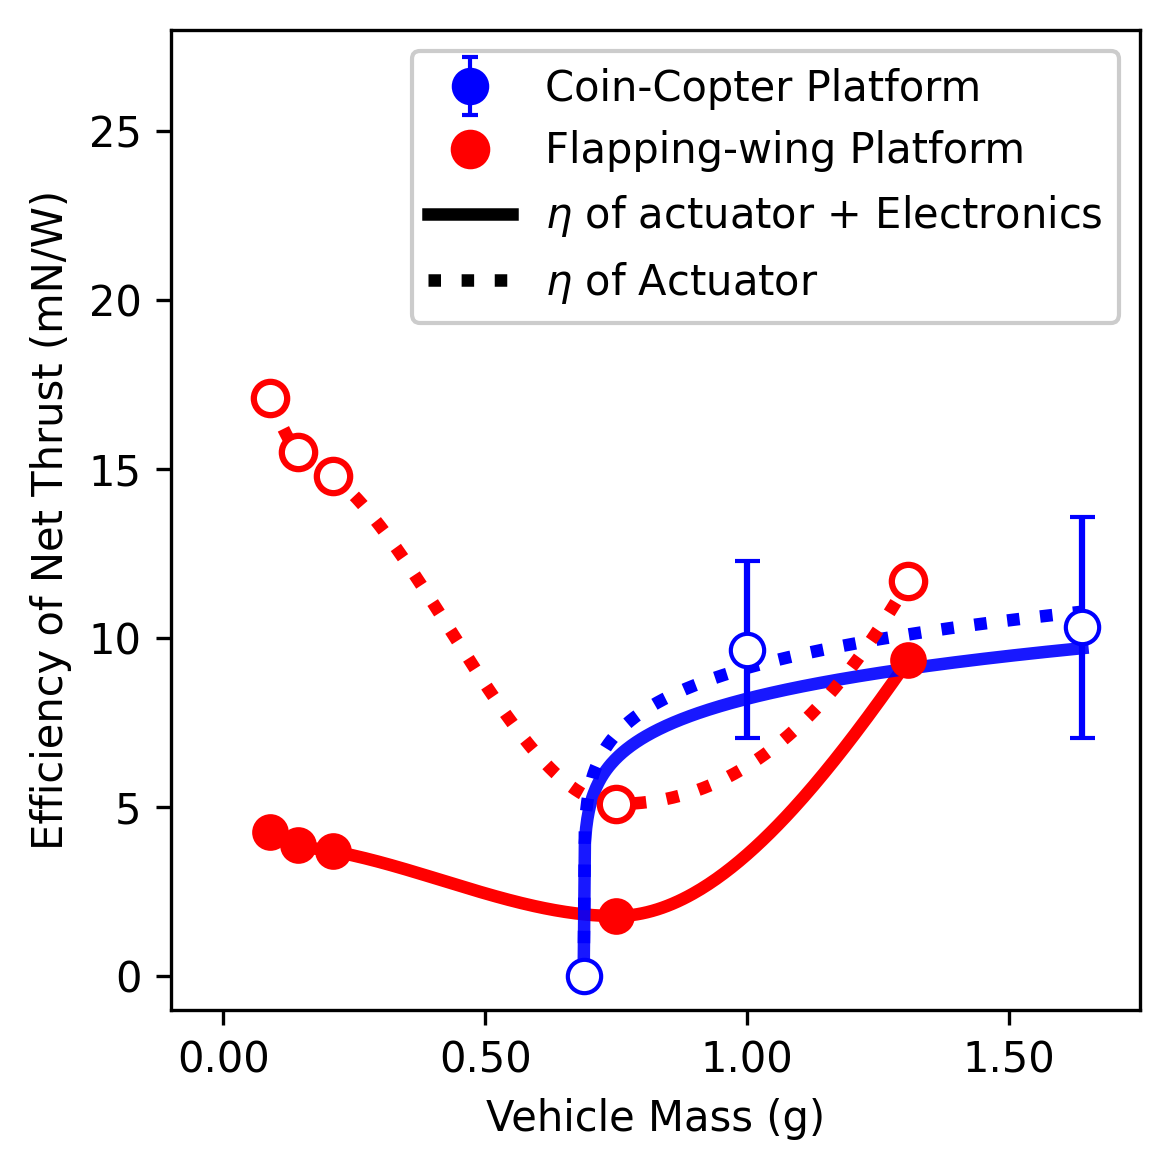

In [ ]:
# Coin-Copter: Mass vs Efficiency of Net Thrust  (y-axis in mN/W)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.container import ErrorbarContainer
from matplotlib.legend_handler import HandlerErrorbar
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator  # smooth-through-points interpolator

# =========================
# Constants
# =========================
B_MAX   = 0.15
GRAM_WT = 0.33
M0_WIN  = 0.02
MARKERSIZE = 8
eta_fit_motor_elec = 0.90

# Plot only first N rows (fits use all rows)
ROW_CAP = 8

# Unit scaling for display: N/W -> mN/W
Y_SCALE = 1e3
def scale(y):  # helper: scale any y-like array/number to mN/W for plotting
    return np.asarray(y, dtype=float) * Y_SCALE

# -------------------------
# Load (rotary + flapping)
# -------------------------
motor_info_sheet_url = "https://docs.google.com/spreadsheets/d/1A2_l8gRRtJzyzayDyE377LKXn18E5xMKtDOolJdjVRI/export?format=csv&gid=0"
flapping_wing_info_sheet_url = "https://docs.google.com/spreadsheets/d/1A2_l8gRRtJzyzayDyE377LKXn18E5xMKtDOolJdjVRI/export?format=csv&gid=1797784260"

df = pd.read_csv(motor_info_sheet_url)
df.columns = df.columns.str.strip()

fw = pd.read_csv(flapping_wing_info_sheet_url)
fw.columns = fw.columns.str.strip()

# -------------------------
# Process (rotary; keep zeros; robust rename)
# -------------------------
df = df.rename(columns={
    'Coin-Copter Variant': 'variant',
    'Coin-Copter Mass (g)': 'mass_mg',  # some sheets store grams; keep key consistent
    'Voltage (V)': 'voltage',
    'Efficiency of Net Thrust (N/W)': 'eta_u',
    'Net Thrust (N)': 'thrust_u',
    'Power (W)': 'power'
})
for col in ['mass_mg', 'voltage', 'eta_u', 'thrust_u', 'power']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Only keep 2/3/4V rows for rotary
df = df[(df['voltage'].isin([2, 3, 4])) & df['mass_mg'].notna() & df['eta_u'].notna()]
df['eta_u'] = df['eta_u'].clip(lower=0)

# -------------------------
# Rotary aggregation (mean/CI)
# -------------------------
means = (df.groupby(['variant', 'mass_mg'], as_index=False)
           .agg(eta_mean=('eta_u', 'mean'),
                eta_std =('eta_u', 'std'),
                n       =('eta_u', 'size')))
means['eta_std']  = means['eta_std'].fillna(0.0)
means['eta_sem']  = means['eta_std'] / np.sqrt(means['n'].clip(lower=1))
means['eta_ci95'] = 1.96 * means['eta_sem']

# Weights for fit
sem_floor = (means.loc[means['eta_sem'] > 0, 'eta_sem'].min() * 0.5
             if (means['eta_sem'] > 0).any() else 1e-3)
sigma = np.where(means['eta_sem'] > 0, means['eta_sem'], sem_floor).astype(float)
for i, r in means.iterrows():
    if str(r['variant']).strip().lower() == 'gram-scale':
        sigma[i] = max(sigma[i] * GRAM_WT, 1e-6)

# Subset to display (fits still use all 'means')
means_plot = means.head(ROW_CAP)

# -------------------------
# Plot rotary (blue)
# -------------------------
fig, ax = plt.subplots(figsize=(4, 4), dpi=300, facecolor='none')
ax.set_facecolor('none')
for _, row in means_plot.iterrows():
    ax.errorbar(row['mass_mg'], scale(row['eta_mean']),
                yerr=scale(row['eta_ci95']), fmt='o', capsize=3, mfc='white',
                color='blue', ecolor='blue', elinewidth=1.5,
                markersize=MARKERSIZE, label='_nolegend_')

# -------------------------
# Rotary fit: eta(m) = a * max(0, m - m0)^b
# -------------------------
def thresh_power(m, a, b, m0):
    return a * np.maximum(0.0, m - m0)**b

masses = means['mass_mg'].to_numpy(dtype=float)
etas   = means['eta_mean'].to_numpy(dtype=float)
pos_mask = etas > 0
m_pos_min = masses[pos_mask].min() if pos_mask.any() else masses.max()

sub_mass = means.loc[means['variant'].str.lower()=='sub-gram', 'mass_mg']
if not sub_mass.empty:
    sub_mass = float(sub_mass.iloc[0])
    m0_lo = max(0.0, sub_mass - M0_WIN)
    m0_hi = min(m_pos_min - 1e-6, sub_mass + M0_WIN)
else:
    m0_lo = 0.0
    m0_hi = m_pos_min - 1e-6

b0 = min(0.55, B_MAX)
z  = np.maximum(0.0, masses - ((m0_lo+m0_hi)/2))**b0
a0 = float((z @ etas) / (z @ z)) if np.any(z > 0) else 1e-3
a0 = max(a0, 1e-6)
p0 = [a0, b0, (m0_lo + m0_hi)/2]

popt, _ = curve_fit(
    thresh_power, masses, etas, p0=p0,
    bounds=([0.0, 0.1, m0_lo], [np.inf, B_MAX, m0_hi]),
    sigma=sigma, absolute_sigma=False, maxfev=80000
)
a_fit, b_fit, m0_fit = popt

# m_smooth = np.linspace(max(0.0, masses.min()), masses.max(), 400)
m_smooth = np.linspace(m0_fit, masses.max(), 400)
eta_fit  = thresh_power(m_smooth, a_fit, b_fit, m0_fit)

# plot (scaled to mN/W)
ax.plot(m_smooth, scale(eta_fit), ':', color='blue', label='_nolegend_', linewidth=3.0)
ax.plot(m_smooth, scale(eta_fit_motor_elec*eta_fit), '-', color='blue', linewidth=3.0, alpha=0.9, label='_nolegend_')

# -------------------------
# Flapping-wing: read/clean
# -------------------------
fw = fw.rename(columns={
    'Flapping-Wing Variant': 'variant',
    'Vehicle Mass (g)': 'mass_mg',
    'Efficiency of Net Thrust (N/W)': 'eta_u',
    'Net Thrust (N)': 'thrust_u',
    'Power (W)': 'power',
    'Voltage (V)': 'voltage',
    'Efficiency of Electronics': 'eta_elec'
})
for col in ['mass_mg', 'eta_u', 'thrust_u', 'power', 'voltage', 'eta_elec']:
    if col in fw.columns:
        fw[col] = pd.to_numeric(fw[col], errors='coerce')

fw = fw[(fw['mass_mg'].notna()) & (fw['eta_u'].notna())]
fw['eta_elec'] = fw['eta_elec'].clip(lower=0) if 'eta_elec' in fw.columns else np.nan
fw['eta_total'] = fw['eta_u'] * fw['eta_elec']  # electronics-included efficiency

fw_plot = fw.head(ROW_CAP)

# -------------------------
# Helper: smooth line that passes through all points (PCHIP)
# -------------------------
def smooth_through_points(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None, None
    df_xy = pd.DataFrame({'x': x[mask], 'y': y[mask]}).groupby('x', as_index=False)['y'].mean()
    if len(df_xy) < 2:
        return None, None
    df_xy = df_xy.sort_values('x')
    xi = df_xy['x'].to_numpy()
    yi = df_xy['y'].to_numpy()
    xs = np.linspace(xi.min(), xi.max(), max(200, len(xi)*50))
    ys = PchipInterpolator(xi, yi)(xs)
    return xs, ys

# -------------------------
# Flapping markers + smooth-through-point curves (scaled to mN/W)
# -------------------------
# 1) Measured efficiency (η_thrust): hollow red rings + dotted smooth line
ax.plot(
    fw_plot['mass_mg'], scale(fw_plot['eta_u']),
    linestyle='None', marker='o',
    markerfacecolor='white', markeredgecolor='red', markeredgewidth=1.5,
    markersize=MARKERSIZE, label='_nolegend_', zorder=3
)
xs_meas, ys_meas = smooth_through_points(fw['mass_mg'], fw['eta_u'])
if xs_meas is not None:
    ax.plot(xs_meas, scale(ys_meas), linestyle=':', linewidth=3.0, color='red', label='_nolegend_', zorder=2)

# 2) Electronics-included efficiency (η_total): filled red dots + solid smooth line
fw_plot_total = fw_plot.dropna(subset=['eta_total'])
ax.plot(
    fw_plot_total['mass_mg'], scale(fw_plot_total['eta_total']),
    linestyle='None', marker='o',
    markerfacecolor='red', markeredgecolor='red', markeredgewidth=0.8,
    markersize=MARKERSIZE, label='_nolegend_', zorder=4
)
fw_total = fw.dropna(subset=['eta_total'])
xs_tot, ys_tot = smooth_through_points(fw_total['mass_mg'], fw_total['eta_total'])
if xs_tot is not None:
    ax.plot(xs_tot, scale(ys_tot), linestyle='-', linewidth=3, color='red', alpha=1.0, label='_nolegend_', zorder=1)

# -------------------------
# LEGEND
# -------------------------
rotary_proxy = ax.errorbar(np.nan, np.nan, yerr=scale(1), fmt='o',
                           color='blue', ecolor='blue',
                           capsize=2, elinewidth=1.0, markersize=MARKERSIZE)

# Replace (0,0) point with (np.nan,np.nan)
flapping_proxy = Line2D([np.nan], [np.nan], linestyle='None', marker='o',
                        markerfacecolor='red', markeredgecolor='red',
                        markeredgewidth=1.5, markersize=MARKERSIZE)

actuator_elec_proxy = Line2D([np.nan], [np.nan], color='black', linewidth=3, linestyle='-')
actuator_proxy      = Line2D([np.nan], [np.nan], color='black', linewidth=3, linestyle=':')

ax.legend(
    [rotary_proxy, flapping_proxy, actuator_elec_proxy, actuator_proxy],
    ['Coin-Copter Platform', 'Flapping-wing Platform', '$\\eta$ of actuator + Electronics', '$\\eta$ of Actuator'],
    handler_map={ErrorbarContainer: HandlerErrorbar(yerr_size=0.7)},
    loc='upper right', facecolor='white', framealpha=1.0
)

# -------------------------
# Cosmetics (y-axis now in mN/W)
# -------------------------
ax.set_xlim(-0.1, 1.75)
ax.set_ylim(scale(-0.001), scale(0.028))  # was -0.001..0.028 N/W → now -1..28 mN/W
ax.set_xlabel('Vehicle Mass (g)')
ax.set_ylabel('Efficiency of Net Thrust (mN/W)')

ax.minorticks_on()
xt = np.asarray(ax.get_xticks())
if not np.isclose(xt, 1.00).any():
    ax.set_xticks(sorted(np.r_[xt, 1.00]))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.minorticks_off()
ax.grid(False)
plt.tight_layout()
# --- make sure the canvas itself is transparent ---
fig.patch.set_alpha(0)   # figure bg transparent
ax.patch.set_alpha(0)    # axes bg transparent
# If you also want a transparent legend, uncomment these two lines:
# leg = ax.get_legend()
# if leg: leg.get_frame().set_alpha(0)  # or leg.get_frame().set_facecolor('none')
out_path = '/content/Efficiency-of-Usable-Thrust_vs_Mass_v4.svg'
fig.savefig(out_path, format='svg', dpi=300, bbox_inches='tight', transparent=True, facecolor='none', edgecolor='none')
from google.colab import files
files.download(out_path)
plt.show()